# Experiment #1:

In this experiment, we will compare the performance of the selected techniques for modeling hierarchical taxonomies from textual data. The goal of this experiment is to find the best performing technique to generated taxonomies for a Knowledge Graph (KG). Therefore the generated triples will be integrated into an existing KG. As baseline model for KG recommender systems we use the current state of the art Graph Neural Network (GNN) model `KGIL`, which the code is available on [GitHub](https://github.com/shuyao-wang/KGIL).

**Data:**
We will use the `Amazon Video Games` dataset. The dataset was published by the McAuley Lab from the University of California, San Diego and contains reviews split into train and test set and metadata of products from Amazon. We will use the latest version of the dataset from 2023. The dataset is for the public available on [HuggingFace]('https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023'). We load the 5-core version of the dataset. To shrink the computational and memory footprint further we filter the dataset to a 10-core version.

**Techniques:**
We will compare the following techniques:
- Hierarchical topic modeling. _This technique is called Topic modeling and a common NLP downstream task. The technique extract information from text document and organize them into a broad topics. In this case, we will use `three diferent embedding models`, `kmeans` as clustering algorithm, `hdbscan` as hierarchical clustering algorithm and `tf-idf` for naming the topics._ 
- Named Entity Recognition. _The second model used is `rebel-large` from [HuggingFace]("https://huggingface.co/Babelscape/rebel-large"). This model is a Named Entity Recognition model. The model is able to extract the entities (Named Entities Recognition) and predict the relations between them (Relation Extraction / classification). This task is a common NLP downstream task and focuses on extracting on word or sentence level information._  
- LLMHierarchyCOL. _This technique was developed by the author of this thesis. The technique uses as LLM `gemma3-3b` from Google DeepMind to generate a detailed product description from a short summary. We load locally from [Ollama]("https://ollama.com/library/llama3.2). The assumption behind the summary detalisation is presented in the thesis. The detailed product description is then used to extract Key Words with the Library `KeyBERT` using the SentenceTransformer model `sentence-transformers/paraphrase-mpnet-base-v2` from [HuggingFace](https://huggingface.co/sentence-transformers/paraphrase-mpnet-base-v2). The extracted keywords will be fed into a LLM using Chain of Layer (COL) to generate, update and review the taxonomy._

Furthermore the techniques extract in different ways on different granularity levels information to organize them.

**Evaluation**:

_Quantitative:_
- Similarities: to observe the differences in the topic clusters between the embedding models we measure the `levenshtein distance` between the topic clusters.
- Performance: To evaluate the performance of the techniques we will use the `KGIL` model as baseline model. We will evaluate the performance of the techniques by measuring the `Precision@20`, `Recall@20`, `NDCG@20` and `Hit Ratio@20`.
- Cost: We measure the time consumption to model the taxonomies and train the KGIL model for each technique and the memory footprint.

_Qualitative:_
- Taxonomy quality: We observe the quality of the generated taxonomies by visualizing them. 
- Error analysis: We conduct an error analysis on the KGIL model for each technique. This will help identify if the taxonomies are useful during the multi-hop reasoning of the KGIL model. Also it help identify if KGIL systematically predicts errors for certain entities.

**Infrastructure:**
The experiments were conducted on a Apple M2 MacBook Pro with 16GB RAM and 10-core CPU.


## 0. Setup

In [2]:
import os # path management
import sys # system path management
import pandas as pd # data manipulation
import numpy as np # data manipulation
from scipy.sparse import csr_matrix # build adjency matrix
import random # random number generation
import torch # for gnn
import networkx as nx # graph library
from sentence_transformers import SentenceTransformer # 

from time import time # time measurement
import Levenshtein # levenshtein distance


sys.path.append('../..')  # Add the project root to the path so we can import from utils

from utils.prepare_data import PrepareData


### Hyperparameters

+ set dataset: _this hyperparameter is used to find the preprocessed dataset in the data/preprocessed folder. aswell it used to find the relations in the data/relations folder and create an experiment folder in the data/experiments folder._

+ set model technique: _this hyperparameter is used to find the model technique in the MODEL_TECHNIQUES list. this is the second parameter in the data path to find preprocessed  and relations data and to store results._

+ experiment name: _this hyperparameter is used to create an experiment folder in the data/experiments folder. the experiment name is used to store the results of the experiment._

In [10]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]

MODEL_TECHNIQUES = ["all-MiniLM-L6-v2","intfloat/multilingual-e5-large-instruct","Alibaba-NLP/gte-Qwen2-1.5B-instruct","gemma3", "ner","baseline"]
current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#1"


In [11]:
# --- Dynamic Hyperparameter Setting ---

EPOCHS = "5" # set epochs small, because the dataset is large
BATCH_SIZE = "5012" # set batch size high, because the dataset is large
TEST_BATCH_SIZE = "5012"  

# 1. EDA


In [12]:
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

In [13]:
metadata_df.head(5)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author,source_text
0,Video Games,NBA 2K17 - Early Tip Off Edition - PlayStation 4,4.3,223,'The #1 rated NBA video game simulation series...,'Following the record-breaking launch of NBA 2...,58.0,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['NBA 2K17 - Kobe: Haters vs Players...,2K,"'Video Games', 'PlayStation 4', 'Games'","Release date: September 16, 2016, Best Sellers...",B00Z9TLVK0,NaN,NaN,NaN,Parent ASIN: B00Z9TLVK0; Title: NBA 2K17 - Ear...
1,Video Games,eXtremeRate Soft Touch Top Shell Front Housing...,4.5,3061,'Compatibility Models: Ultra fits for Xbox One...,NaN,17.59,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",eXtremeRate,"'Video Games', 'Xbox One', 'Accessories', 'Fac...","Best Sellers Rank: Video Games: 48130, Xbox On...",B07H93H878,NaN,NaN,NaN,Parent ASIN: B07H93H878; Title: eXtremeRate So...
2,Video Games,Konami Collector's Series: Castlevania & Contr...,3.6,19,This collection of classic 8-bit games include...,The Konami Collector's Series: Castlevania & C...,NaN,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': [""Konami Collector's Series: Arcade ...",Square Enix,"'Video Games', 'PC', 'Games'","Release date: December 2, 2002, Best Sellers R...",B00006969T,NaN,NaN,NaN,Parent ASIN: B00006969T; Title: Konami Collect...
3,Video Games,Tales of Vesperia - Definitive Edition - PlayS...,4.8,1389,'A BELOVED TALE RETURNS! — The tale of a young...,A power struggle begins in a Civilization depe...,20.95,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['Tales of Vesperia - Definitive Edi...,BANDAI NAMCO Entertainment,"'Video Games', 'PlayStation 4', 'Games'","Release date: January 11, 2019, Best Sellers R...",B07DL353F8,NaN,NaN,NaN,Parent ASIN: B07DL353F8; Title: Tales of Vespe...
4,Video Games,Turbo: Super Stunt Squad - Nintendo 3DS,4.1,26,'Play as your favorite snails from the movie -...,"'Product Description', 'Turbo: Super Stunt Squ...",4.97,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['Turbo: Super Stunt Squad - Launch'...,D3 Publisher,"'Video Games', 'Legacy Systems', 'Nintendo Sys...","Release date: July 16, 2013, Best Sellers Rank...",B00BJH85SW,NaN,NaN,NaN,Parent ASIN: B00BJH85SW; Title: Turbo: Super S...


Number of unique items: 24370
Number of unique users: 91513
Training set size:  732653
Training set unique items:  22134
Training set unique users:  91513
Test set size:  41803
Test set unique items:  7096
Test set unique users:  13622


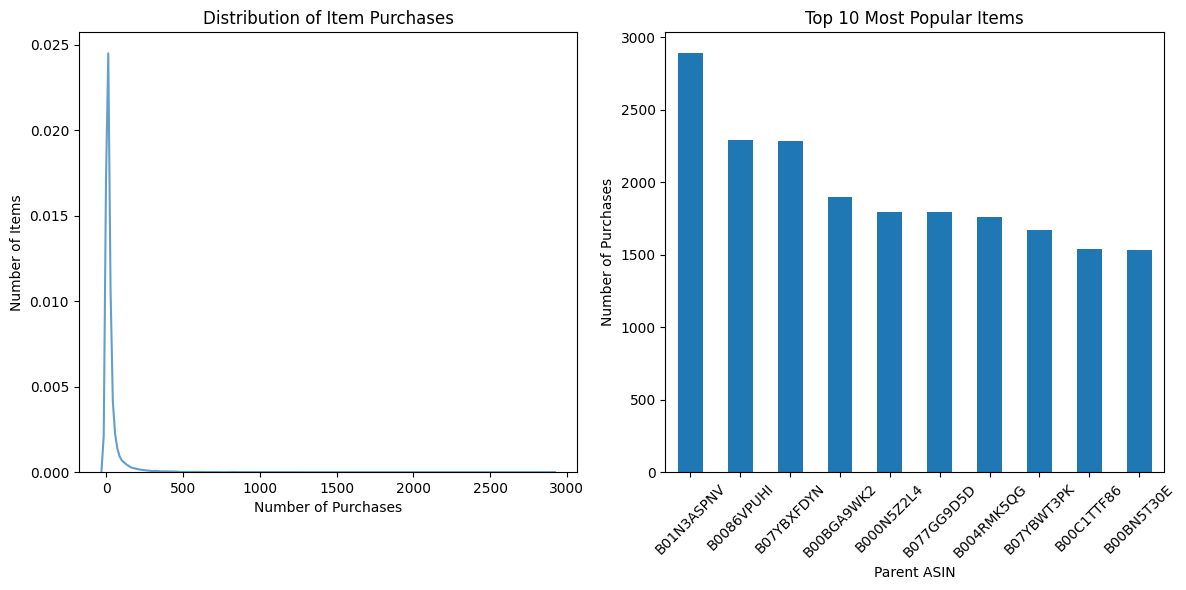


Item Purchase Distribution Statistics:
Mean purchases per item: 31.78
Median purchases per item: 12.00
Max purchases for an item: 2890
Min purchases for an item: 1
Standard deviation: 78.47

User Statistics:
 Average purchases per user: 8.01
 Median purchases per user: 6.00
 Max purchases for a user: 473
 Min purchases for a user: 1
 Standard deviation: 7.76

Text Data Statistics:
Average tokens per item: 355.69
Max tokens for an item: 16119
Min tokens for an item: 21


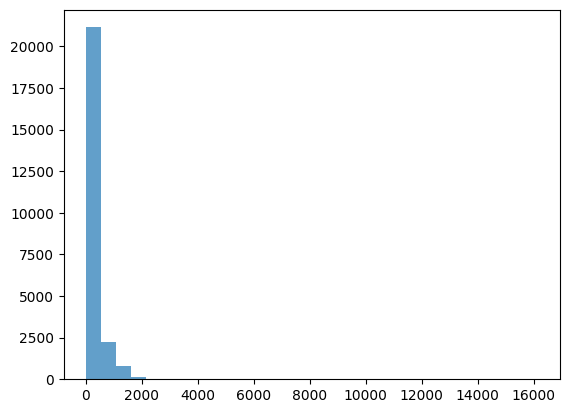

In [14]:
#Exploratory Data Analysis (EDA)
from matplotlib import pyplot as plt
import seaborn as sns
print(f"Number of unique items: {metadata_df.shape[0]}")
print(f"Number of unique users: {len(train_df['user_id'].unique())}")
print("Training set size: ", train_df.shape[0])
print("Training set unique items: ", train_df['parent_asin'].nunique())
print("Training set unique users: ", train_df['user_id'].nunique())
print("Test set size: ", test_df.shape[0])
print("Test set unique items: ", test_df['parent_asin'].nunique())
print("Test set unique users: ", test_df['user_id'].nunique())

# Distribution of item purchases (popularity)
item_purchase_counts = pd.concat([train_df['parent_asin'], test_df['parent_asin']]).value_counts()
top_items = item_purchase_counts.head(10)

# Plotting the distribution of item purchases
plt.figure(figsize=(12, 6))

# Plot histogram of item purchase counts
plt.subplot(1, 2, 1)
sns.kdeplot(item_purchase_counts, alpha=0.7)
plt.title('Distribution of Item Purchases')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Items')

# Plot top 10 most popular items
plt.subplot(1, 2, 2)
top_items.plot(kind='bar')
plt.title('Top 10 Most Popular Items')
plt.xlabel('Parent ASIN')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Basic statistics of purchase distribution
print("\nItem Purchase Distribution Statistics:")
print(f"Mean purchases per item: {item_purchase_counts.mean():.2f}")
print(f"Median purchases per item: {item_purchase_counts.median():.2f}")
print(f"Max purchases for an item: {item_purchase_counts.max()}")
print(f"Min purchases for an item: {item_purchase_counts.min()}")
print(f"Standard deviation: {item_purchase_counts.std():.2f}")

# Basic user statistics
print("\nUser Statistics:")
print(f" Average purchases per user: {train_df['user_id'].value_counts().mean():.2f}")
print(f" Median purchases per user: {train_df['user_id'].value_counts().median():.2f}")
print(f" Max purchases for a user: {train_df['user_id'].value_counts().max()}")
print(f" Min purchases for a user: {train_df['user_id'].value_counts().min()}")
print(f" Standard deviation: {train_df['user_id'].value_counts().std():.2f}")

# Check for text data statistics if available
if 'source_text' in metadata_df.columns:
    # Calculate token counts (approximation by word count)
    metadata_df['token_count'] = metadata_df['source_text'].str.split().str.len()
    
    print("\nText Data Statistics:")
    print(f"Average tokens per item: {metadata_df['token_count'].mean():.2f}")
    print(f"Max tokens for an item: {metadata_df['token_count'].max()}")
    print(f"Min tokens for an item: {metadata_df['token_count'].min()}")

plt.hist(metadata_df['token_count'], bins=30, alpha=0.7)
plt.show()

NOTED TO BE UPDATED, look at notebook amazon_beauty

## 2. Experiment

### 2.1 Baseline

In [15]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
DATASET = DATASETS[2]

MODEL_TECHNIQUE = MODEL_TECHNIQUES[5].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)
os.makedirs(EXPERIMENT_DATA_PATH, exist_ok=True)

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# because the baseline kg only uses the user-item interactions, we need to create a kg with only the user-item interactions
prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)

kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg_without_taxonomy(train_df, test_df,EXPERIMENT_DATA_PATH)
kg_df.to_csv(EXPERIMENT_DATA_PATH+'/'+f'{MODEL_TECHNIQUE}_relations.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
kg_df = kg_df[['head','relation','tail']]
kg_df.to_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')
baseline_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline
Combined KG has 774456 unique triples.
Found 118589 unique entities.
Found 1 unique relations.
Mapped 732653 train interactions.
Mapped 41803 test interactions.
Mapped KG has 774456 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline


: 

In [16]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCHS])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])

n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    baseline_density = nx.density(graph)
    print(f"Density of the graph: {baseline_density}")
    baseline_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {baseline_avg_degree}")
    baseline_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {baseline_max_degree}")
    #baseline_depth = nx.average_shortest_path_length(graph)
    #print(f"Average shortest path length of the graph: {baseline_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret,baseline_predictions = test(model, user_dict, n_params)
        # save predictions
        baseline_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        baseline_metrics_table = PrettyTable()
        baseline_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            baseline_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            baseline_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            baseline_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            baseline_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        baseline_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        baseline_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        baseline_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        baseline_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        baseline_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(baseline_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/baseline/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 91513/91513 [00:00<00:00, 1689526.30it/s]



Begin to load knowledge graph triples ...


100%|##########| 1548912/1548912 [00:06<00:00, 248681.54it/s]


End to build graph ... MultiDiGraph with 118589 nodes and 1548912 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 3/3 [00:00<00:00,  8.00it/s]


Density of the graph: 0.00011013911762486838
Average degree of the graph: 26.122355361795783
Max degree of the graph: 5780
Dataset statistics:
Number of training interactions: 91513
Number of test interactions: 13622
Number of users: 94219
Number of items: 118581
Batch size: 5012
start training ...

Epoch 1/5
Number of iterations expected: 18
Processing 91513 samples in batches of 5012

First batch statistics:
Users shape: torch.Size([5012])
Positive items shape: torch.Size([5012])
Negative items shape: torch.Size([5012])

Iteration 0 losses:
rec_loss: 0.448474
inv_mean: 2.209805
inv_var: 0.000250
outer_loss: 0.470574

Gradient norms:
all_embed: 1.084888
latent_emb: 0.000065
gcn.weight: 0.160552
gcn.disen_weight_att: 0.001616
gcn.invariant_generator.kg_W_r: 0.000000
augmenter.edge_mlp_list.0.0.weight: 0.000016
augmenter.edge_mlp_list.0.0.bias: 0.000010
augmenter.edge_mlp_list.0.2.weight: 0.000007
augmenter.edge_mlp_list.0.2.bias: 0.000008
augmenter.edge_mlp_list.1.0.weight: 0.000002
au

Python(95871) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95872) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95873) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95874) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95875) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


### 2.2 Hierarchical Topic Modeling
#### 2.2.1 all-MiniLM-L6-v2

In [42]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]

MODEL_TECHNIQUE = MODEL_TECHNIQUES[0].replace('/', '_')


In [43]:

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
all_mini_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')

prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(all_mini_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct
Combined KG has 800495 unique triples.
Found 119959 unique entities.
Found 3 unique relations.
Mapped 732653 train interactions.
Mapped 41803 test interactions.
Mapped KG has 800495 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Game

In [44]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list
    
    """Graph statistics"""
    all_mini_density = nx.density(graph)
    print(f"Density of the graph: {all_mini_density}")
    all_mini_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {all_mini_avg_degree}")
    all_mini_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {all_mini_max_degree}")
    all_mini_depth = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {all_mini_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret,all_mini_predictions = test(model, user_dict, n_params)
        # save predictions
        all_mini_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        all_mini_metrics_table = PrettyTable()
        all_mini_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            all_mini_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            all_mini_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            all_mini_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            all_mini_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        all_mini_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        all_mini_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        all_mini_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        all_mini_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        all_mini_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(all_mini_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 91513/91513 [00:00<00:00, 1450836.64it/s]



Begin to load knowledge graph triples ...


100%|##########| 1600990/1600990 [00:08<00:00, 184376.31it/s]


End to build graph ... MultiDiGraph with 119959 nodes and 1600990 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0010  |
|     NDCG@20      |  0.0015  |
|   Precision@20   |  0.0005  |
|   Hit_Ratio@20   |  0.0090  |
|    Recall@40     |  0.0018  |
|     NDCG@40      |  0.0021  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0164  |
|    Recall@60     |  0.0025  |
|     NDCG@60      |  0.0025  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0222  |
|    Recall@80     |  0.0032  |
|     NDCG@80      |  0.0029  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0283  |
|    Recall@100    |  0.0038  |
|     NDCG@100     |  0.0032  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0340  |
|       AUC        |  0.0000  |
| Train Time (min) |   4.88   |
| Test Time (min)  |   1.28   |
|    Outer Loss    | 0.362553 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

Python(77884) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(77885) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(77886) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(77887) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(77888) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before th

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0010  |
|     NDCG@20      |  0.0015  |
|   Precision@20   |  0.0005  |
|   Hit_Ratio@20   |  0.0090  |
|    Recall@40     |  0.0018  |
|     NDCG@40      |  0.0020  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0165  |
|    Recall@60     |  0.0026  |
|     NDCG@60      |  0.0025  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0229  |
|    Recall@80     |  0.0033  |
|     NDCG@80      |  0.0029  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0289  |
|    Recall@100    |  0.0038  |
|     NDCG@100     |  0.0032  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0341  |
|       AUC        |  0.0000  |
| Train Time (min) |   4.46   |
| Test Time (min)  |   1.30   |
|    Outer Loss    | 0.360626 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

Python(78952) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78953) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78954) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78955) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(78956) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before th

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0010  |
|     NDCG@20      |  0.0014  |
|   Precision@20   |  0.0004  |
|   Hit_Ratio@20   |  0.0090  |
|    Recall@40     |  0.0019  |
|     NDCG@40      |  0.0020  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0170  |
|    Recall@60     |  0.0026  |
|     NDCG@60      |  0.0025  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0232  |
|    Recall@80     |  0.0033  |
|     NDCG@80      |  0.0029  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0291  |
|    Recall@100    |  0.0039  |
|     NDCG@100     |  0.0032  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0344  |
|       AUC        |  0.0000  |
| Train Time (min) |   4.70   |
| Test Time (min)  |   1.53   |
|    Outer Loss    | 0.360079 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

#### 2.2.2 intfloat/multilingual-e5-large-instruct

build triplets from hierarchies for selected techniques

In [45]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
MODEL_TECHNIQUE = MODEL_TECHNIQUES[1].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [46]:

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
e5_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')

prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(e5_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct
Combined KG has 792662 unique triples.
Found 118604 unique entities.
Found 3 unique relations.
Mapped 732653 train interactions.
Mapped 41803 test interactions.
Mapped KG has 792662 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/a

set dataset configuration in parser

In [47]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])

n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    """Graph statistics"""
    e5_density = nx.density(graph)
    print(f"Density of the graph: {e5_density}")
    e5_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {e5_avg_degree}")
    e5_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {e5_max_degree}")
    e5_depth = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {e5_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, e5_predictions = test(model, user_dict, n_params)
        # save predictions
        e5_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        e5_metrics_table = PrettyTable()
        e5_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            e5_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            e5_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            e5_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            e5_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        e5_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        e5_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        e5_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        e5_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        e5_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(e5_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/intfloat_multilingual-e5-large-instruct/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 91513/91513 [00:00<00:00, 1728550.77it/s]



Begin to load knowledge graph triples ...


100%|##########| 1585324/1585324 [00:08<00:00, 186085.06it/s]


End to build graph ... MultiDiGraph with 118604 nodes and 1585324 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0011  |
|     NDCG@20      |  0.0018  |
|   Precision@20   |  0.0006  |
|   Hit_Ratio@20   |  0.0111  |
|    Recall@40     |  0.0019  |
|     NDCG@40      |  0.0024  |
|   Precision@40   |  0.0005  |
|   Hit_Ratio@40   |  0.0192  |
|    Recall@60     |  0.0027  |
|     NDCG@60      |  0.0030  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0267  |
|    Recall@80     |  0.0033  |
|     NDCG@80      |  0.0033  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0322  |
|    Recall@100    |  0.0039  |
|     NDCG@100     |  0.0037  |
|  Precision@100   |  0.0004  |
|  Hit_Ratio@100   |  0.0382  |
|       AUC        |  0.0000  |
| Train Time (min) |   5.62   |
| Test Time (min)  |   1.65   |
|    Outer Loss    | 0.362590 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

Python(89355) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(89356) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(89357) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(89358) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(89359) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before th

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0011  |
|     NDCG@20      |  0.0018  |
|   Precision@20   |  0.0006  |
|   Hit_Ratio@20   |  0.0113  |
|    Recall@40     |  0.0020  |
|     NDCG@40      |  0.0025  |
|   Precision@40   |  0.0005  |
|   Hit_Ratio@40   |  0.0196  |
|    Recall@60     |  0.0027  |
|     NDCG@60      |  0.0030  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0264  |
|    Recall@80     |  0.0032  |
|     NDCG@80      |  0.0033  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0322  |
|    Recall@100    |  0.0039  |
|     NDCG@100     |  0.0038  |
|  Precision@100   |  0.0004  |
|  Hit_Ratio@100   |  0.0390  |
|       AUC        |  0.0000  |
| Train Time (min) |   5.70   |
| Test Time (min)  |   1.38   |
|    Outer Loss    | 0.361312 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

Python(90288) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90289) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90290) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90291) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(90292) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before th

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0011  |
|     NDCG@20      |  0.0018  |
|   Precision@20   |  0.0006  |
|   Hit_Ratio@20   |  0.0113  |
|    Recall@40     |  0.0019  |
|     NDCG@40      |  0.0025  |
|   Precision@40   |  0.0005  |
|   Hit_Ratio@40   |  0.0192  |
|    Recall@60     |  0.0027  |
|     NDCG@60      |  0.0030  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0267  |
|    Recall@80     |  0.0033  |
|     NDCG@80      |  0.0033  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0324  |
|    Recall@100    |  0.0039  |
|     NDCG@100     |  0.0037  |
|  Precision@100   |  0.0004  |
|  Hit_Ratio@100   |  0.0382  |
|       AUC        |  0.0000  |
| Train Time (min) |   5.00   |
| Test Time (min)  |   1.53   |
|    Outer Loss    | 0.359104 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

#### 2.2.3 Alibaba-NLP/gte-Qwen2-1.5B-instruct

In [48]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here

MODEL_TECHNIQUE = MODEL_TECHNIQUES[2].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [51]:

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
qwen2_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')
prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(qwen2_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct
Combined KG has 793884 unique triples.
Found 119562 unique entities.
Found 3 unique relations.
Mapped 732653 train interactions.
Mapped 41803 test interactions.
Mapped KG has 19428 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games

In [53]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list
   
    """Graph statistics"""
    qwen2_density = nx.density(graph)
    print(f"Density of the graph: {qwen2_density}")
    qwen2_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {qwen2_avg_degree}")
    qwen2_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {qwen2_max_degree}")
    
    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, qwen2_predictions = test(model, user_dict, n_params)
        # save predictions
        qwen2_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        qwen2_metrics_table = PrettyTable()
        qwen2_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            qwen2_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            qwen2_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            qwen2_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            qwen2_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        qwen2_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        qwen2_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        qwen2_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        qwen2_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        qwen2_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(qwen2_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/Alibaba-NLP_gte-Qwen2-1.5B-instruct/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 91513/91513 [00:00<00:00, 1531266.32it/s]



Begin to load knowledge graph triples ...


100%|##########| 38778/38778 [00:00<00:00, 598668.00it/s]


End to build graph ... MultiDiGraph with 19165 nodes and 38778 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0007  |
|     NDCG@20      |  0.0016  |
|   Precision@20   |  0.0005  |
|   Hit_Ratio@20   |  0.0095  |
|    Recall@40     |  0.0011  |
|     NDCG@40      |  0.0019  |
|   Precision@40   |  0.0003  |
|   Hit_Ratio@40   |  0.0139  |
|    Recall@60     |  0.0014  |
|     NDCG@60      |  0.0022  |
|   Precision@60   |  0.0003  |
|   Hit_Ratio@60   |  0.0178  |
|    Recall@80     |  0.0016  |
|     NDCG@80      |  0.0024  |
|   Precision@80   |  0.0003  |
|   Hit_Ratio@80   |  0.0211  |
|    Recall@100    |  0.0019  |
|     NDCG@100     |  0.0026  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0253  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.26   |
| Test Time (min)  |   1.30   |
|    Outer Loss    | 0.532124 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

Python(93431) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93432) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93433) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93434) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you c

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0007  |
|     NDCG@20      |  0.0016  |
|   Precision@20   |  0.0005  |
|   Hit_Ratio@20   |  0.0096  |
|    Recall@40     |  0.0011  |
|     NDCG@40      |  0.0019  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0140  |
|    Recall@60     |  0.0014  |
|     NDCG@60      |  0.0022  |
|   Precision@60   |  0.0003  |
|   Hit_Ratio@60   |  0.0181  |
|    Recall@80     |  0.0016  |
|     NDCG@80      |  0.0024  |
|   Precision@80   |  0.0003  |
|   Hit_Ratio@80   |  0.0211  |
|    Recall@100    |  0.0019  |
|     NDCG@100     |  0.0026  |
|  Precision@100   |  0.0002  |
|  Hit_Ratio@100   |  0.0246  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.26   |
| Test Time (min)  |   1.61   |
|    Outer Loss    | 0.531425 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

Python(93822) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93823) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93824) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93825) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(93826) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0008  |
|     NDCG@20      |  0.0016  |
|   Precision@20   |  0.0005  |
|   Hit_Ratio@20   |  0.0098  |
|    Recall@40     |  0.0011  |
|     NDCG@40      |  0.0020  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0145  |
|    Recall@60     |  0.0015  |
|     NDCG@60      |  0.0023  |
|   Precision@60   |  0.0003  |
|   Hit_Ratio@60   |  0.0188  |
|    Recall@80     |  0.0017  |
|     NDCG@80      |  0.0025  |
|   Precision@80   |  0.0003  |
|   Hit_Ratio@80   |  0.0221  |
|    Recall@100    |  0.0019  |
|     NDCG@100     |  0.0027  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0252  |
|       AUC        |  0.0000  |
| Train Time (min) |   0.26   |
| Test Time (min)  |   1.30   |
|    Outer Loss    | 0.531945 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

regex similarity between taxnonmy of embedding models

In [54]:
def collect_unique_values(df):
    unique_values = []
    for column in ['head', 'tail']:  # Only consider head and tail columns where entities are stored
        if column in df.columns:
            # Convert to string and filter out nans
            values = df[column].dropna().astype(str).unique().tolist()
            unique_values.extend(values)
    
    # Filter parent ASINs (product IDs that start with 'B')
    unique_values = [value for value in unique_values if isinstance(value, str) and not value.startswith('B')]
    
    # Only unique values
    unique_values = list(set(unique_values))
    return unique_values

# Now use the function
def levenshtein_distance(df1, df2):
    """Calculate normalized Levenshtein distance between two sets of taxonomy terms"""
    
    # Get unique values from each DataFrame (excluding product IDs)
    unique_values_df1 = collect_unique_values(df1)
    unique_values_df2 = collect_unique_values(df2)
    
    
    # Calculate Levenshtein ratio for each pair of terms
    total_similarity = 0
    valid_comparisons = 0
    
    for term1 in unique_values_df1:
        for term2 in unique_values_df2:
            # Skip if either term is not a valid string
            if not isinstance(term1, str) or not isinstance(term2, str):
                continue
                
            lev_ratio = Levenshtein.ratio(term1.lower(), term2.lower())
            total_similarity += lev_ratio
            valid_comparisons += 1
    
    # Avoid division by zero
    if valid_comparisons == 0:
        return 0
        
    avg_lev_ratio = total_similarity / valid_comparisons
    return avg_lev_ratio

e5_qwen2_lev_ratio = levenshtein_distance(e5_triplet_df, qwen2_triplet_df)
e5_mini_lev_ratio = levenshtein_distance(e5_triplet_df, all_mini_triplet_df)
qwen2_mini_lev_ratio = levenshtein_distance(qwen2_triplet_df, all_mini_triplet_df)

print(f"Levenshtein distance between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: {e5_qwen2_lev_ratio}") 
print(f"Levenshtein distance between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: {e5_mini_lev_ratio}")    
print(f"Levenshtein distance between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: {qwen2_mini_lev_ratio}")

Levenshtein distance between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: 0.14504460071430791
Levenshtein distance between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: 0.1423402917776587
Levenshtein distance between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: 0.34166582624382363


In [55]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Fix the cosine_similarity function to handle matrix inputs correctly
def cosine_similarity_matrices(matrix1, matrix2):
    # Transpose the second matrix to align dimensions for dot product
    matrix2_transposed = matrix2.T
    # Calculate dot product between matrices
    dot_product = np.dot(matrix1, matrix2_transposed)
    
    # Calculate norms for each row in both matrices
    norm_matrix1 = np.linalg.norm(matrix1, axis=1, keepdims=True)
    norm_matrix2 = np.linalg.norm(matrix2, axis=1, keepdims=True)
    
    # Calculate cosine similarity
    cosine_sim = dot_product / (np.dot(norm_matrix1, norm_matrix2.T))
    
    return cosine_sim

# Update the calc_cosine_similarity function to use the correct similarity function
def calc_cosine_similarity_fixed(df1, df2, embedding_model):
    def collect_unique_values(df):
        """Collect unique non-ASIN values from head and tail columns."""
        unique_values = []
        for column in ['head', 'tail']:
            if column in df.columns:
                # Drop NaN values, convert to strings, then get unique values
                values = df[column].dropna().astype(str).unique().tolist()
                # Filter out ASINs (product IDs starting with 'B')
                values = [val for val in values if not val.startswith('B')]
                unique_values.extend(values)
        
        # Remove duplicates
        unique_values = list(set(unique_values))
        return unique_values
    
    # Get unique values from each dataframe
    unique_values_df1 = collect_unique_values(df1)
    unique_values_df2 = collect_unique_values(df2)
    
    
    # Skip if either list is empty
    if not unique_values_df1 or not unique_values_df2:
        print("Warning: One or both term lists are empty, returning 0")
        return 0

    # Embed unique values
    unique_values_df1_embed = embedding_model.encode(unique_values_df1)
    unique_values_df2_embed = embedding_model.encode(unique_values_df2)

    # Use the fixed cosine similarity function for matrices
    cosine_similarity_matrix = cosine_similarity_matrices(unique_values_df1_embed, unique_values_df2_embed).mean()

    return cosine_similarity_matrix

print(f"Cosine similarity between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: {calc_cosine_similarity_fixed(e5_triplet_df, qwen2_triplet_df, embedding_model)}")
print(f"Cosine similarity between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: {calc_cosine_similarity_fixed(e5_triplet_df, all_mini_triplet_df, embedding_model)}")
print(f"Cosine similarity between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: {calc_cosine_similarity_fixed(qwen2_triplet_df, all_mini_triplet_df, embedding_model)}")


Cosine similarity between multi-lingual-e5-large-instruct and gte-Qwen2-1.5-instruct: 0.23463201522827148
Cosine similarity between multi-lingual-e5-large-instruct and all-MiniLM-L6-v2: 0.21720252931118011
Cosine similarity between gte-Qwen2-1.5-instruct and all-MiniLM-L6-v2: 0.35538557171821594


To measure similarity between the different constructed topics of the different embedding models cosine similarity seems to be the better similarity measure. As displayed in the above the embedding models in BERTTopic generate lexical very different topics with the same meaning. The levenstein similarity for all scenarios is lower compared to the cosine similarity. Levenstein similarity is between 0.13 and 0.34 meanwhile the cosine similarity is between 0.22 and 0.36. 

![BERTopic Algorithm](https://maartengr.github.io/BERTopic/algorithm/default.svg)


Looking at the BERTTopic algorithm gives an explanation for this. 
To create topic represantation BERTTopic uses after a clustering a Bag-of-Words (CountVectorizer). It counts how often words appears in a given cluster. Further it uses a TF-IDF transformation to weight the words to focus on specific words in a cluster. In this case the created cluster seems to be similar, but not the same. Therefore curtent words may apear less in the cluster and wont be used in the TF-IDF transformation. On the other hand the intersection of the topics provide semantically similar topics which can be seen in the cosine similarity.

### 2.3 Hearst-Patterns Named-Entity-Recognition (Rebel-large)

In [73]:

MODEL_TECHNIQUE = MODEL_TECHNIQUES[4].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [74]:

data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')

# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
rebel_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_relations.csv')
len_before = len(rebel_triplet_df)
# filter out relation where one column is empty
rebel_triplet_df = rebel_triplet_df[rebel_triplet_df['head'].notna() & rebel_triplet_df['tail'].notna()]
len_after = len(rebel_triplet_df)
filtered_out = len_before - len_after
print(f"Filtered out {filtered_out} relations where one column is empty")

prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(rebel_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Filtered out 32127 relations where one column is empty
Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner
Combined KG has 816106 unique triples.
Found 134200 unique entities.
Found 115 unique relations.
Mapped 732653 train interactions.
Mapped 41803 test interactions.
Mapped KG has 816106 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner


In [76]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    """Graph statistics"""
    rebel_density = nx.density(graph)
    print(f"Density of the graph: {rebel_density}")
    rebel_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {rebel_avg_degree}")
    rebel_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {rebel_max_degree}")
    rebel_depth = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {rebel_depth}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, rebel_predictions = test(model, user_dict, n_params)
        # save predictions
        rebel_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        rebel_metrics_table = PrettyTable()
        rebel_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            rebel_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            rebel_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            rebel_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            rebel_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        rebel_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        rebel_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        rebel_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        rebel_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        rebel_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(rebel_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/ner/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 91513/91513 [00:00<00:00, 1700921.48it/s]



Begin to load knowledge graph triples ...


100%|##########| 1632212/1632212 [00:06<00:00, 261969.72it/s]


End to build graph ... MultiDiGraph with 134200 nodes and 1632212 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0006  |
|     NDCG@20      |  0.0013  |
|   Precision@20   |  0.0005  |
|   Hit_Ratio@20   |  0.0098  |
|    Recall@40     |  0.0010  |
|     NDCG@40      |  0.0018  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0161  |
|    Recall@60     |  0.0014  |
|     NDCG@60      |  0.0022  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0227  |
|    Recall@80     |  0.0018  |
|     NDCG@80      |  0.0025  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0280  |
|    Recall@100    |  0.0021  |
|     NDCG@100     |  0.0028  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0337  |
|       AUC        |  0.0000  |
| Train Time (min) |   6.21   |
| Test Time (min)  |   2.74   |
|    Outer Loss    | 0.361220 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

Python(27883) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27884) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27885) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27886) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27887) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The cur

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0006  |
|     NDCG@20      |  0.0013  |
|   Precision@20   |  0.0005  |
|   Hit_Ratio@20   |  0.0098  |
|    Recall@40     |  0.0010  |
|     NDCG@40      |  0.0018  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0165  |
|    Recall@60     |  0.0014  |
|     NDCG@60      |  0.0022  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0230  |
|    Recall@80     |  0.0018  |
|     NDCG@80      |  0.0025  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0285  |
|    Recall@100    |  0.0022  |
|     NDCG@100     |  0.0028  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0343  |
|       AUC        |  0.0000  |
| Train Time (min) |   5.60   |
| Test Time (min)  |   2.55   |
|    Outer Loss    | 0.358763 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

Python(29120) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29121) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29122) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29123) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29124) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before th

Test iter:[0/2]
Test iter:[1/2]

Evaluation Metrics:
+------------------+----------+
|      Metric      |  Value   |
+------------------+----------+
|    Recall@20     |  0.0006  |
|     NDCG@20      |  0.0013  |
|   Precision@20   |  0.0005  |
|   Hit_Ratio@20   |  0.0098  |
|    Recall@40     |  0.0010  |
|     NDCG@40      |  0.0018  |
|   Precision@40   |  0.0004  |
|   Hit_Ratio@40   |  0.0167  |
|    Recall@60     |  0.0014  |
|     NDCG@60      |  0.0022  |
|   Precision@60   |  0.0004  |
|   Hit_Ratio@60   |  0.0230  |
|    Recall@80     |  0.0018  |
|     NDCG@80      |  0.0025  |
|   Precision@80   |  0.0004  |
|   Hit_Ratio@80   |  0.0285  |
|    Recall@100    |  0.0022  |
|     NDCG@100     |  0.0028  |
|  Precision@100   |  0.0003  |
|  Hit_Ratio@100   |  0.0343  |
|       AUC        |  0.0000  |
| Train Time (min) |   5.59   |
| Test Time (min)  |   2.51   |
|    Outer Loss    | 0.357618 |
|    Inner Loss    | 0.000000 |
+------------------+----------+
-------------------

### 2.4 LLM-Col-Hierarchy-Tax (Gemma 3)


In [14]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASET = DATASETS[2]

MODEL_TECHNIQUE = MODEL_TECHNIQUES[3].replace('/', '_')
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

In [15]:
# Load relations
triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy-triples.csv')
data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
train_df = pd.read_csv(data_path+'/train_df.csv')
test_df = pd.read_csv(data_path+'/test_df.csv')
prepare_data = PrepareData()
train_df = prepare_data.user_item_triples(train_df)
test_df = prepare_data.user_item_triples(test_df)
kg_df, train_adj, test_adj, name_to_id_map = prepare_data.build_kg(gemma_triplet_df, train_df, test_df,EXPERIMENT_DATA_PATH)


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3
Combined KG has 782328 unique triples.
Found 118627 unique entities.
Found 3 unique relations.
Mapped 732653 train interactions.
Mapped 41803 test interactions.
Mapped KG has 782328 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3


In [16]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
# sys.argv[0] is typically the path to the ipykernel launcher, keep it.
sys.argv = [sys.argv[0]]
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
n_users = 0
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0


def get_feed_dict(train_entity_pairs, start, end, train_user_set):

    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                                train_user_set)).to(device)
    return feed_dict


def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph


def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch


if __name__ == '__main__':
    """fix the random seed"""
    seed = 2020
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """read args"""
    global args, device
    args = parse_args()
    device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

    """build dataset"""
    train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
    adj_mat_list, norm_mat_list, mean_mat_list = mat_list

    gemma_density = nx.density(graph)
    print(f"Density of the graph: {gemma_density}")
    gemma_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
    print(f"Average degree of the graph: {gemma_avg_degree}")
    gemma_max_degree = max(dict(nx.degree(graph)).values())
    print(f"Max degree of the graph: {gemma_max_degree}")
    gemma_avg_shortest_path_length = nx.average_shortest_path_length(graph)
    print(f"Average shortest path length of the graph: {gemma_avg_shortest_path_length}")

    print(f"Dataset statistics:")
    print(f"Number of training interactions: {len(train_cf)}")
    print(f"Number of test interactions: {len(test_cf)}")
    print(f"Number of users: {n_params['n_users']}")
    print(f"Number of items: {n_params['n_items']}")
    print(f"Batch size: {args.batch_size}")

    n_users = n_params['n_users']
    n_items = n_params['n_items']
    n_entities = n_params['n_entities']
    n_relations = n_params['n_relations']
    n_nodes = n_params['n_nodes']
    
    """cf data"""
    train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
    test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

    """define model"""
    augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
    model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
    
    """define optimizer"""
    rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
    model.augmenter = augmenter

    cur_best_pre_0 = 0
    stopping_step = 0
    should_stop = False
    total_iter = max(len(train_cf) // args.batch_size, 1)
    get_print = max(total_iter // 20, 1)
    
    print("start training ...")
    for epoch in range(args.epoch):
        # Add epoch start print
        print(f"\nEpoch {epoch+1}/{args.epoch}")
        print(f"Number of iterations expected: {total_iter}")
        
        index = np.arange(len(train_cf))
        np.random.shuffle(index)
        model.train()

        train_cf_pairs = train_cf_pairs[index]
        total_outer_loss, total_inner_loss, s = 0, 0, 0
        train_s_t = time()
        iteration = 0
        
        # Add batch processing print
        print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
        
        while s + args.batch_size <= len(train_cf):
            batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
            
            # Debug print for first batch of first epoch
            if epoch == 0 and iteration == 0:
                print("\nFirst batch statistics:")
                print(f"Users shape: {batch['users'].shape}")
                print(f"Positive items shape: {batch['pos_items'].shape}")
                print(f"Negative items shape: {batch['neg_items'].shape}")
            
            rec_loss, inv_mean, inv_var = model(batch)
            outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
            
            # Debug print losses
            if iteration % 100 == 0:
                print(f"\nIteration {iteration} losses:")
                print(f"rec_loss: {rec_loss.item():.6f}")
                print(f"inv_mean: {inv_mean.item():.6f}")
                print(f"inv_var: {inv_var.item():.6f}")
                print(f"outer_loss: {outer_loss.item():.6f}")
            
            rec_optimizer.zero_grad()
            outer_loss.backward()
            
            # Check gradients periodically
            if iteration % 10 == 0:
                print("\nGradient norms:")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm(2).item()
                        print(f"{name}: {grad_norm:.6f}")
            
            rec_optimizer.step()
            total_outer_loss += outer_loss.item()

            if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                # Debug augmenter update
                rec_loss, inv_mean, inv_var = model(batch)
                inner_loss = - inv_var
                
                if iteration == 12:  # First augmenter update
                    print(f"\nAugmenter update:")
                    print(f"inner_loss: {inner_loss.item():.6f}")
                    print(f"inv_var: {inv_var.item():.6f}")
                
                aug_optimizer.zero_grad()
                inner_loss.backward()
                
                # Debug augmenter gradients
                if iteration == 12:
                    print("\nAugmenter gradient norms:")
                    for name, param in augmenter.named_parameters():
                        if param.grad is not None:
                            print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                
                aug_optimizer.step()
                total_inner_loss += inner_loss.item()

            s += args.batch_size
            iteration += 1
            inner_loss = - inv_var
            if iteration % get_print == 0:
                print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                .format(epoch + 1, args.epoch, 
                        iteration, total_iter, 
                        outer_loss.item(), 
                        inner_loss.item(),
                        (time() - train_s_t) / 60))

        train_e_t = time()
        print("-" * 100)
        print("start evluation ...")
        print("-" * 100)
        test_s_t = time()
        ret, gemma_predictions = test(model, user_dict, n_params)
        # save predictions
        gemma_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv", index=False)
        test_e_t = time()
        epoch_outer_loss = total_outer_loss  / total_iter
        epoch_inner_loss = total_inner_loss  / total_iter
        train_time = (train_e_t - train_s_t) / 60
        test_time = (test_e_t - test_s_t) / 60
        
        # Create a pretty table for metrics
        gemma_metrics_table = PrettyTable()
        gemma_metrics_table.field_names = ["Metric", "Value"]
        
        # Add all available metrics
        for k_idx, k in enumerate(eval(args.Ks)):
            gemma_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
            gemma_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
            gemma_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
            gemma_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
        
        gemma_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
        gemma_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
        gemma_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
        gemma_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
        gemma_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
        
        print("\nEvaluation Metrics:")
        print(gemma_metrics_table)
        print("-" * 100)
        
        # Keep the original print for consistency
        recall_20 = ret['recall'][0]
        ndcg_20 = ret['ndcg'][0]
        print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
            .format(epoch + 1, args.epoch, 
                    epoch_outer_loss, epoch_inner_loss,
                    recall_20, ndcg_20,
                    train_time, test_time))
        print("-" * 100)
        

Train file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/train_adj.txt
Test file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/test_adj.txt
KG file: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1/amazon-Video_Games/gemma3/kg_final.txt
reading train and test user-item set ...
combinating train_cf and kg data ...
building the graph ...
Begin to build graph ... MultiDiGraph with 0 nodes and 0 edges
Begin to load interaction triples ...


100%|##########| 91513/91513 [00:00<00:00, 1801256.46it/s]



Begin to load knowledge graph triples ...


100%|##########| 1564656/1564656 [00:05<00:00, 290121.99it/s]


End to build graph ... MultiDiGraph with 118627 nodes and 1564656 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 7/7 [00:00<00:00, 18.73it/s]


Density of the graph: 0.00011118736441815635
Average degree of the graph: 26.37942458293643
Max degree of the graph: 5780
Average shortest path length of the graph: 4.275134151995542
Dataset statistics:
Number of training interactions: 91513
Number of test interactions: 13622
Number of users: 94219
Number of items: 118591
Batch size: 10000
start training ...

Epoch 1/10
Number of iterations expected: 9
Processing 91513 samples in batches of 10000

First batch statistics:
Users shape: torch.Size([10000])
Positive items shape: torch.Size([10000])
Negative items shape: torch.Size([10000])

Iteration 0 losses:
rec_loss: 0.439399
inv_mean: 2.207452
inv_var: 0.000038
outer_loss: 0.461474

Gradient norms:
all_embed: 1.149608
latent_emb: 0.000018
gcn.weight: 0.138059
gcn.disen_weight_att: 0.000434
gcn.invariant_generator.kg_W_r: 0.000000
augmenter.edge_mlp_list.0.0.weight: 0.000003
augmenter.edge_mlp_list.0.0.bias: 0.000003
augmenter.edge_mlp_list.0.2.weight: 0.000001
augmenter.edge_mlp_list.0

## 3. Results

In [17]:
# Create a function to safely extract metrics from tables
def safe_extract_metrics(metrics_df, method_name):
    metrics = {}
    metrics['Method'] = method_name
    
    # Check if metrics_df is a PrettyTable
    if hasattr(metrics_df, 'get_string'):
        # Extract data from PrettyTable
        for row in metrics_df._rows:
            if row[0] == 'Recall@20':
                metrics['Recall@20'] = float(row[1])
            elif row[0] == 'Precision@20':
                metrics['Precision@20'] = float(row[1])
            elif row[0] == 'NDCG@20':
                metrics['NDCG@20'] = float(row[1])
            elif row[0] == 'Hit_Ratio@20':
                metrics['Hit_Ratio@20'] = float(row[1])
            elif row[0] == 'AUC':
                metrics['AUC'] = float(row[1])
    else:
        # Assume it's a DataFrame
        try:
            metrics['Recall@20'] = metrics_df.loc[metrics_df.index == 'Recall@20', 'Value'].iloc[0]
            metrics['Precision@20'] = metrics_df.loc[metrics_df.index == 'Precision@20', 'Value'].iloc[0]
            metrics['NDCG@20'] = metrics_df.loc[metrics_df.index == 'NDCG@20', 'Value'].iloc[0]
            metrics['Hit_Ratio@20'] = metrics_df.loc[metrics_df.index == 'Hit_Ratio@20', 'Value'].iloc[0]
            metrics['AUC'] = metrics_df.loc[metrics_df.index == 'AUC', 'Value'].iloc[0]
        except:
            # Default values if metrics are missing
            metrics['Recall@20'] = 0.0
            metrics['Precision@20'] = 0.0
            metrics['NDCG@20'] = 0.0
            metrics['Hit_Ratio@20'] = 0.0
            metrics['AUC'] = 0.0
    
    return metrics

# Use the safe extraction function instead
baseline_key_metrics = safe_extract_metrics(baseline_metrics_table, "Baseline")
e5_key_metrics = safe_extract_metrics(e5_metrics_table, "Hierarchical-Topic-e5-large-instruct")
all_mini_key_metrics = safe_extract_metrics(all_mini_metrics_table, "Hierarchical-Topic-MiniLM-L6-v2")
qwen2_key_metrics = safe_extract_metrics(qwen2_metrics_table, "Hierarchical-Topic-gte-Qwen2-1.5B-instruct")
rebel_key_metrics = safe_extract_metrics(rebel_metrics_table, "Hearst-Patterns NER-Rebel-large")
gemma_key_metrics = safe_extract_metrics(gemma_metrics_table, "LLM-Col-Hierarchy-Tax")

results_list = [baseline_key_metrics, e5_key_metrics, all_mini_key_metrics, qwen2_key_metrics, rebel_key_metrics, gemma_key_metrics]


# Find the best and second best values for each metric
metrics_to_compare = ['Recall@20', 'Precision@20', 'NDCG@20', 'Hit_Ratio@20']
best_values = {}
second_best_values = {}

for metric in metrics_to_compare:
    # Extract values for this metric from all methods
    values = [result[metric] for result in results_list]
    # Sort values in descending order
    sorted_values = sorted(values, reverse=True)
    
    # Store best and second best values
    if len(sorted_values) >= 1:
        best_values[metric] = sorted_values[0]
    if len(sorted_values) >= 2:
        second_best_values[metric] = sorted_values[1]

# Calculate delta for Gemma3 compared to baseline
gemma_deltas = {}

for metric in metrics_to_compare:
    gemma_value = gemma_key_metrics[metric]
    
    # Delta to best
    if metric in best_values:
        if gemma_value == best_values[metric]:
            # If Gemma is the best, compare to second best
            if metric in second_best_values:
                delta = gemma_value - second_best_values[metric]
                gemma_deltas[f"{metric}"] = delta
                gemma_deltas[f"{metric}"] = (delta / second_best_values[metric]) * 100 if second_best_values[metric] != 0 else float('inf')
        else:
            # If Gemma is not the best, compare to best
            delta = gemma_value - best_values[metric]
            gemma_deltas[f"{metric}"] = (delta / best_values[metric]) * 100 if best_values[metric] != 0 else float('inf')
# add to results_list
results_list[5]['LLM-Col-Hierarchy-Tax_Delta'] = gemma_deltas

# Create a pretty table to display the results
from prettytable import PrettyTable

acc_comparison_table = PrettyTable()
acc_comparison_table.field_names = ["Method", "Recall@20", "Precision@20", "NDCG@20", "Hit_Ratio@20"]

# Add rows to the table
for result in results_list:
    acc_comparison_table.add_row([
        result['Method'],
        f"{result['Recall@20']:.4f}",
        f"{result['Precision@20']:.4f}",
        f"{result['NDCG@20']:.4f}",
        f"{result['Hit_Ratio@20']:.4f}",
    ])

# add gemma3_delta to the table
acc_comparison_table.add_row([
    "Delta LLM-Col-Hierarchy-Tax (%)",
    f"{gemma_deltas['Recall@20']:.4f}",
    f"{gemma_deltas['Precision@20']:.4f}",
    f"{gemma_deltas['NDCG@20']:.4f}",
    f"{gemma_deltas['Hit_Ratio@20']:.4f}",
])

# Display the comparison table
print("Comparison of Different Taxonomy Methods:")
print(acc_comparison_table)

# Optionally, create a bar chart to visualize the comparison
import matplotlib.pyplot as plt
import numpy as np

# Check if we have results to plot
if results_list:
    # Extract method names and metrics
    method_names = [result['Method'] for result in results_list]
    recall_values = [result['Recall@20'] for result in results_list]
    precision_values = [result['Precision@20'] for result in results_list]
    ndcg_values = [result['NDCG@20'] for result in results_list]
    hr_values = [result['Hit_Ratio@20'] for result in results_list]
    
    # Set up the figure
    fig, axs = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle('Comparison of Taxonomy Methods', fontsize=16)
    
    # Create bar charts for each metric
    metrics = [recall_values, precision_values, ndcg_values, hr_values]
    metric_names = ['Recall@20', 'Precision@20', 'NDCG@20', 'Hit_Ratio@20']
    
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        row, col = i // 2, i % 2
        axs[row, col].bar(method_names, metric, color='skyblue')
        axs[row, col].set_title(name)
        axs[row, col].set_ylim(0, max(metric) * 1.2)  # Add some space above the bars
        axs[row, col].set_xticklabels(method_names, rotation=45, ha='right')
    
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()
else:
    print("No results available to plot.")


NameError: name 'e5_metrics_table' is not defined

In [ ]:
df_kg_stats = pd.DataFrame(columns=['Method', 'Density', 'Average Degree', 'Max Degree', 'Average Shortest Path Length'])
df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Baseline"], 
    "Density": [baseline_density], 
    "Average Degree": [baseline_avg_degree], 
    "Max Degree": [baseline_max_degree], 
    "Average Shortest Path Length": [baseline_depth]
})], ignore_index=True)

df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hierarchical-Topic-MiniLM-L6-v2"], 
    "Density": [all_mini_density], 
    "Average Degree": [all_mini_avg_degree], 
    "Max Degree": [all_mini_max_degree], 
    "Average Shortest Path Length": [all_mini_depth]
})], ignore_index=True)

df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hierarchical-Topic-e5-large-instruct"], 
    "Density": [e5_density], 
    "Average Degree": [e5_avg_degree], 
    "Max Degree": [e5_max_degree], 
    "Average Shortest Path Length": [e5_depth]
})], ignore_index=True)
df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hierarchical-Topic-gte-Qwen2-1.5B-instruct"], 
    "Density": [qwen2_density], 
    "Average Degree": [qwen2_avg_degree], 
    "Max Degree": [qwen2_max_degree], 
    "Average Shortest Path Length": [0]
})], ignore_index=True)
df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    "Method": ["Hearst-Patterns NER-Rebel-large"], 
    "Density": [rebel_density], 
    "Average Degree": [rebel_avg_degree], 
    "Max Degree": [rebel_max_degree], 
    "Average Shortest Path Length": [rebel_depth]
})], ignore_index=True)

df_kg_stats = pd.concat([df_kg_stats, pd.DataFrame({
    'Method': ['LLM-Col-Hierarchy-Tax'], 
    'Density': [gemma_density], 
    'Average Degree': [gemma_avg_degree], 
    'Max Degree': [gemma_max_degree], 
    'Average Shortest Path Length': [0]
})], ignore_index=True)


# transform acc_comparison_table to df
acc_comparison_df = pd.DataFrame(acc_comparison_table.rows, columns=["Method", "Recall@20", "Precision@20", "NDCG@20", "Hit_Ratio@20"])
acc_comparison_df = acc_comparison_df[acc_comparison_df['Method'] != 'Delta LLM-Col-Hierarchy-Tax (%)']

# Create DataFrame excluding the delta row
acc_comparison_df = pd.DataFrame(acc_comparison_df, columns=["Method", "Recall@20", "Precision@20", "NDCG@20", "Hit_Ratio@20"])


In [ ]:
# relationship between density and ncdg@20
# corr between density and ncdg@20
density_ndcg_corr = df_kg_stats['Density'].corr(acc_comparison_df['NDCG@20'])
print(f"Correlation between Density and NCDG@20: {density_ndcg_corr:.4f}")
density_rec_corr = df_kg_stats['Density'].corr(acc_comparison_df['Recall@20'])
print(f"Correlation between Density and Recall@20: {density_rec_corr:.4f}")

fig, axs = plt.subplots(1,2, figsize=(10,5),dpi=100)
fig.suptitle('Relationship between Density and Recall@20 / NCDG@20')
axs[0].scatter(df_kg_stats['Density'], acc_comparison_df['NDCG@20'])
axs[0].set_xlabel('Density')
axs[0].set_ylabel('NDCG@20')

axs[1].scatter(df_kg_stats['Density'], acc_comparison_df['Recall@20'])
axs[1].set_xlabel('Density')
axs[1].set_ylabel('Recall@20')
plt.show()

In [ ]:
# relationship between max degree and recall@20
max_rec_corr = df_kg_stats['Max Degree'].corr(acc_comparison_df['Recall@20'])
print(f"Correlation between Max Degree and Recall@20: {max_rec_corr:.4f}")
max_ndcg_corr = df_kg_stats['Max Degree'].corr(acc_comparison_df['NDCG@20'])
print(f"Correlation between Max Degree and NCDG@20: {max_ndcg_corr:.4f}")

fig, axs = plt.subplots(1,2, figsize=(10,5),dpi=100)
fig.suptitle('Relationship between Max Degree and Recall@20 / NCDG@20')
axs[0].scatter(df_kg_stats['Max Degree'], acc_comparison_df['NDCG@20'])
axs[0].set_xlabel('Max Degree')
axs[0].set_ylabel('NDCG@20')

axs[1].scatter(df_kg_stats['Max Degree'], acc_comparison_df['Recall@20'])
axs[1].set_xlabel('Max Degree')
axs[1].set_ylabel('Recall@20')
plt.show()


## 3. Interpretation and Discussion